# Step 1 — Geographic Concentration & Market Dependency
**Objective:** Understand who Brazil's top trading partners are and how those relationships have evolved over 30 years.

This notebook follows a macro-to-micro structure:
1. Total trade value by year (exports vs imports)
2. Top trading partners nationally over time
3. Structural shifts — key moments and transitions
4. Share of trade by regional bloc over time

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data is capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR = 2025

Connected to database successfully


## 1.1 — Total Trade Value by Year (Exports vs Imports)
The broadest possible view: how has Brazil's total trade volume evolved since 1997?

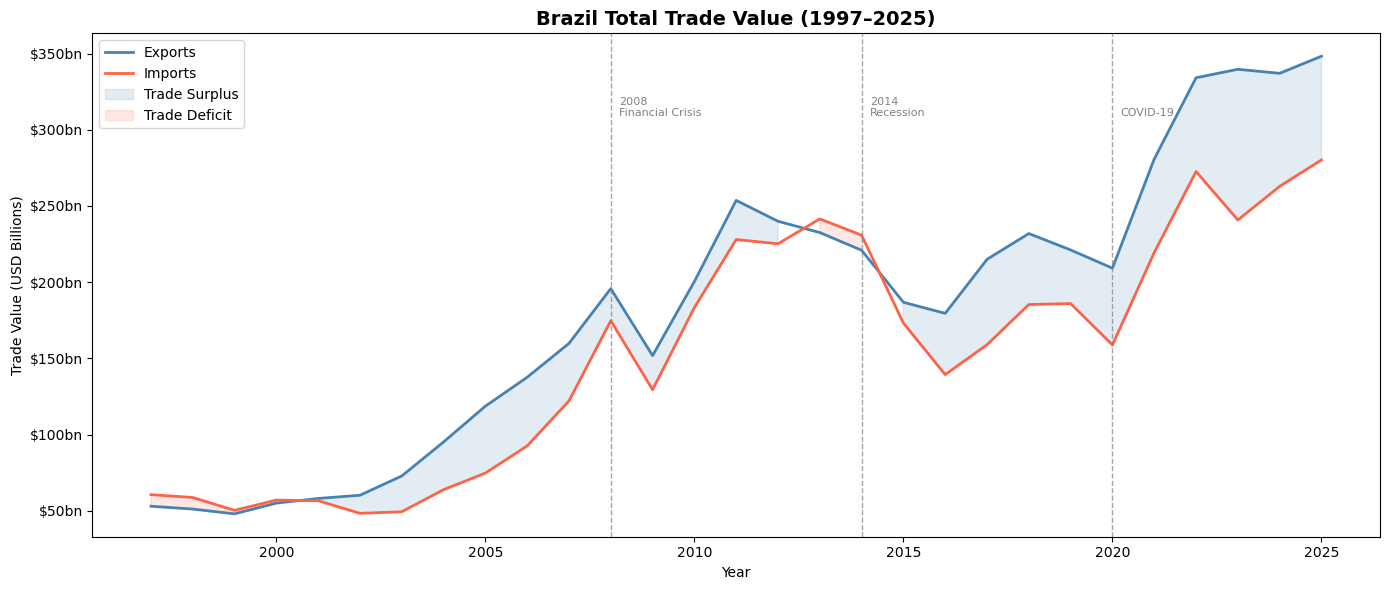

    year     total_fob  total_usd_bn
24  2021  2.808146e+11    280.814577
25  2022  3.341360e+11    334.136038
26  2023  3.396958e+11    339.695766
27  2024  3.370462e+11    337.046162
28  2025  3.482785e+11    348.278462


In [2]:
query_total = f"""
    SELECT "CO_ANO" AS year,
           SUM("VL_FOB") AS total_fob
    FROM exp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO"
"""

query_total_imp = f"""
    SELECT "CO_ANO" AS year,
           SUM("VL_FOB") AS total_fob
    FROM imp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO"
"""

df_exp_total = pd.read_sql(query_total, engine)
df_imp_total = pd.read_sql(query_total_imp, engine)

# Convert to USD billions
df_exp_total['total_usd_bn'] = df_exp_total['total_fob'] / 1e9
df_imp_total['total_usd_bn'] = df_imp_total['total_fob'] / 1e9

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_exp_total['year'], df_exp_total['total_usd_bn'], label='Exports', color='steelblue', linewidth=2)
ax.plot(df_imp_total['year'], df_imp_total['total_usd_bn'], label='Imports', color='tomato', linewidth=2)
ax.fill_between(df_exp_total['year'], df_exp_total['total_usd_bn'], df_imp_total['total_usd_bn'],
                where=df_exp_total['total_usd_bn'] >= df_imp_total['total_usd_bn'],
                alpha=0.15, color='steelblue', label='Trade Surplus')
ax.fill_between(df_exp_total['year'], df_exp_total['total_usd_bn'], df_imp_total['total_usd_bn'],
                where=df_exp_total['total_usd_bn'] < df_imp_total['total_usd_bn'],
                alpha=0.15, color='tomato', label='Trade Deficit')

# Annotate key events
events = {2008: '2008\nFinancial Crisis', 2014: '2014\nRecession', 2020: 'COVID-19'}
for year, label in events.items():
    ax.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(year + 0.2, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')

ax.set_title(f"Brazil Total Trade Value (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Value (USD Billions)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_1_total_trade.png', dpi=150)
plt.show()
print(df_exp_total.tail())

## 1.2 — Top 10 Export Partners by Year
Which countries have received the most Brazilian exports, and how has that ranking evolved?

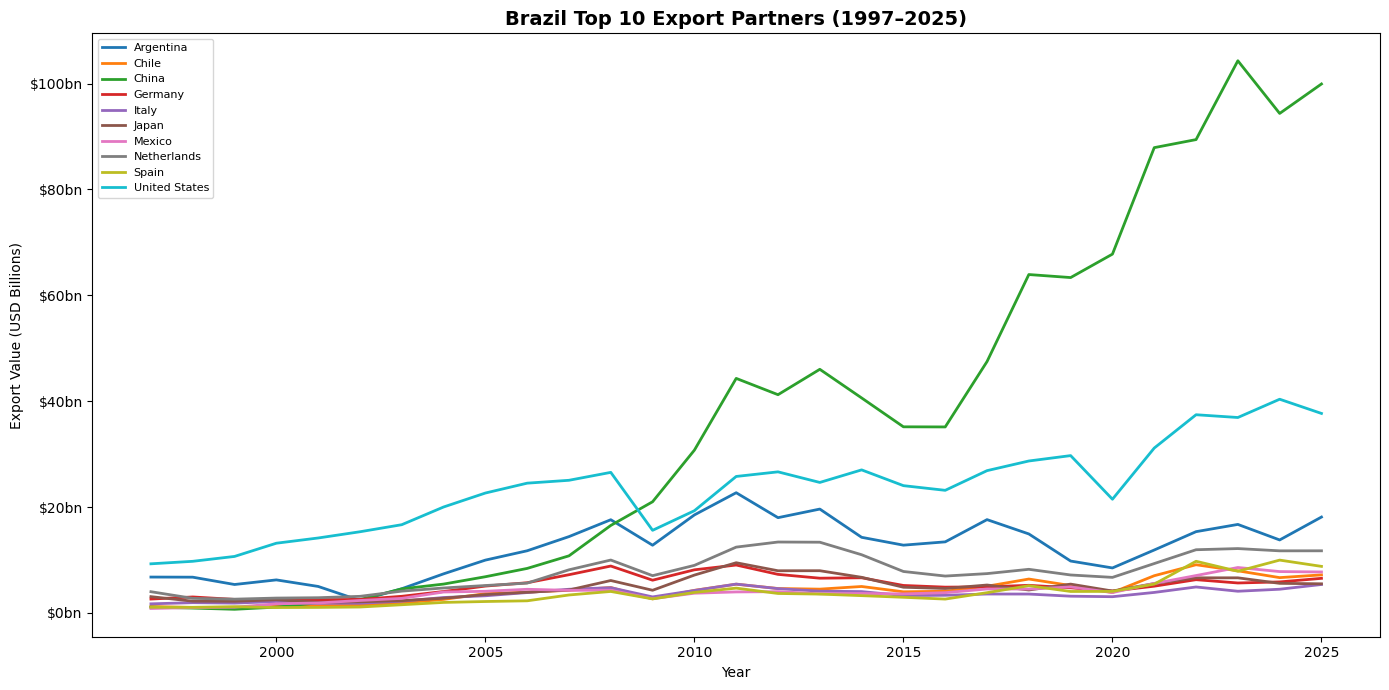

In [3]:
query_top_partners = f"""
    SELECT e."CO_ANO" AS year,
           p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", p.nome_pais_ing
    ORDER BY e."CO_ANO", total_fob DESC
"""

df_partners = pd.read_sql(query_top_partners, engine)
df_partners['total_usd_bn'] = df_partners['total_fob'] / 1e9

# Get top 10 countries by total exports across all years
top10_countries = (
    df_partners.groupby('country')['total_fob']
    .sum()
    .nlargest(10)
    .index.tolist()
)

df_top10 = df_partners[df_partners['country'].isin(top10_countries)]

# Pivot for plotting
df_pivot = df_top10.pivot(index='year', columns='country', values='total_usd_bn').fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
for country in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[country], label=country, linewidth=2)

ax.set_title(f"Brazil Top 10 Export Partners (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_2_top10_export_partners.png', dpi=150)
plt.show()

## 1.3 — China vs USA: The Structural Shift
One of the most significant structural changes in Brazilian trade over the last 30 years is China overtaking the United States as Brazil's largest trading partner. This cell isolates that story.

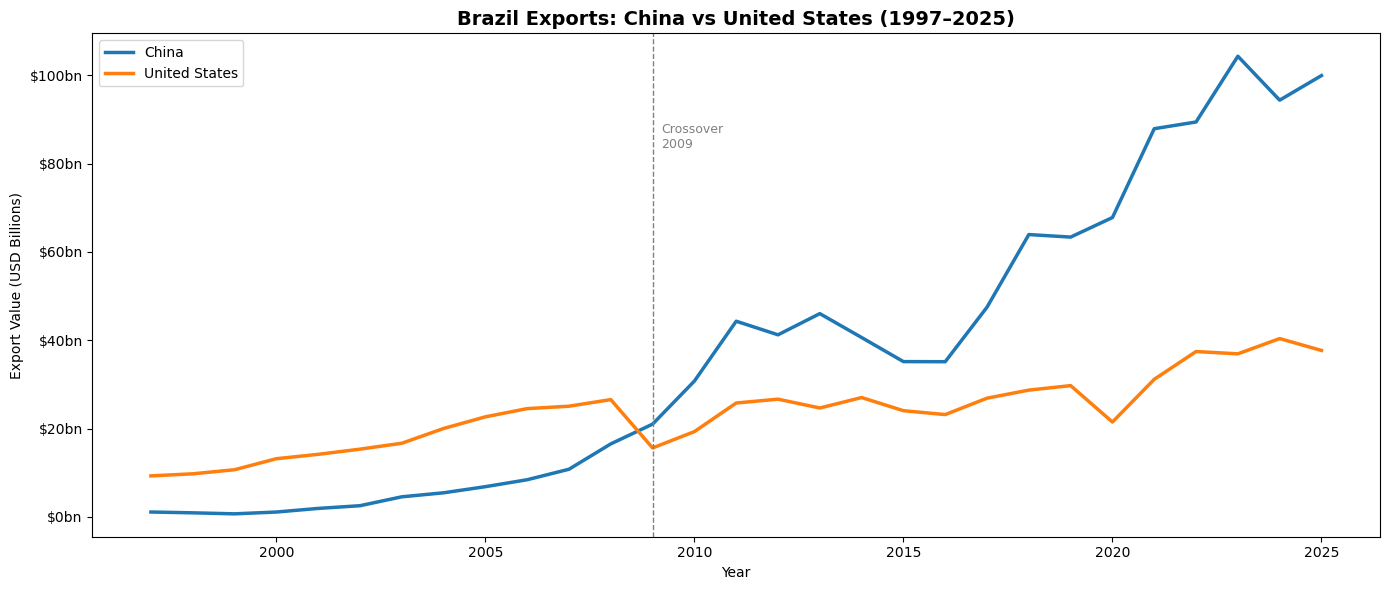

In [5]:
query_china_usa = f"""
    SELECT e."CO_ANO" AS year,
           p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE p.nome_pais_ing IN ('China', 'United States')
    AND e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", p.nome_pais_ing
    ORDER BY e."CO_ANO"
"""

df_china_usa = pd.read_sql(query_china_usa, engine)
df_china_usa['total_usd_bn'] = df_china_usa['total_fob'] / 1e9
df_pivot_cu = df_china_usa.pivot(index='year', columns='country', values='total_usd_bn').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for country in df_pivot_cu.columns:
    ax.plot(df_pivot_cu.index, df_pivot_cu[country], label=country, linewidth=2.5)

# Find and annotate the crossover year
cols = df_pivot_cu.columns.tolist()
if len(cols) == 2:
    crossover = df_pivot_cu[df_pivot_cu[cols[0]] > df_pivot_cu[cols[1]]].index
    if len(crossover) > 0:
        ax.axvline(x=crossover[0], color='gray', linestyle='--', linewidth=1)
        ax.text(crossover[0] + 0.2, df_pivot_cu.max().max() * 0.8,
                f'Crossover\n{crossover[0]}', fontsize=9, color='gray')

ax.set_title(f"Brazil Exports: China vs United States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_1_3_china_vs_usa.png', dpi=150)
plt.show()

## 1.4 — Share of Trade by Regional Bloc Over Time
How has the distribution of Brazilian trade across regional blocs (Mercosul, EU, Asia, etc.) shifted over 30 years?

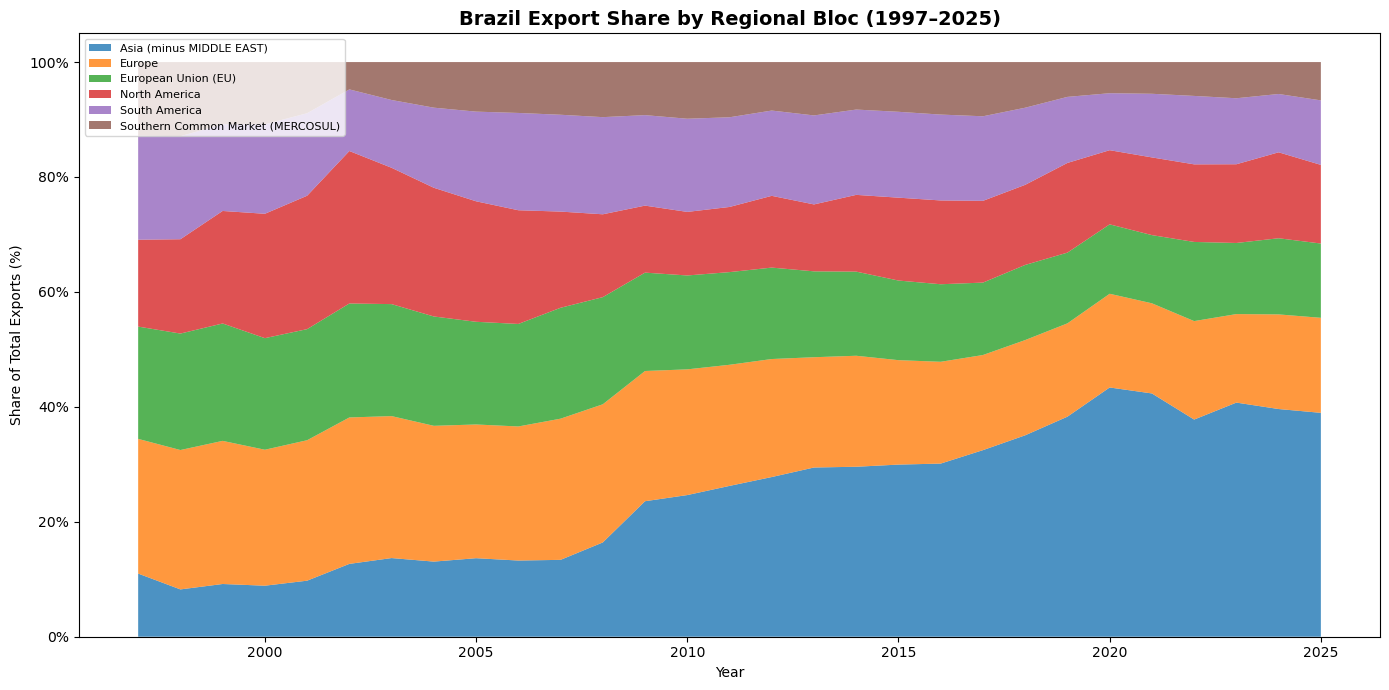

In [6]:
query_blocs = f"""
    SELECT e."CO_ANO" AS year,
           pb.nome_bloco_ing AS bloc,
           SUM(e."VL_FOB") AS total_fob
    FROM exp e
    JOIN pais_bloco pb ON e."CO_PAIS" = pb.codigo_pais
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", pb.nome_bloco_ing
    ORDER BY e."CO_ANO", total_fob DESC
"""

df_blocs = pd.read_sql(query_blocs, engine)
df_blocs['total_usd_bn'] = df_blocs['total_fob'] / 1e9

# Get top 6 blocs by total trade
top6_blocs = (
    df_blocs.groupby('bloc')['total_fob']
    .sum()
    .nlargest(6)
    .index.tolist()
)

df_blocs_top = df_blocs[df_blocs['bloc'].isin(top6_blocs)]
df_blocs_pivot = df_blocs_top.pivot(index='year', columns='bloc', values='total_usd_bn').fillna(0)

# Normalise to percentage share
df_blocs_pct = df_blocs_pivot.div(df_blocs_pivot.sum(axis=1), axis=0) * 100

# Stacked area chart
fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(df_blocs_pct.index, df_blocs_pct.T, labels=df_blocs_pct.columns, alpha=0.8)

ax.set_title(f"Brazil Export Share by Regional Bloc (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Share of Total Exports (%)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_1_4_bloc_share.png', dpi=150)
plt.show()

## 1.5 — Summary Table: Top 10 Partners (Most Recent Year)
A clean summary of the current state — who are Brazil's top 10 export and import partners today?

In [7]:
## 2026 data excluded — only partial year available, which distorts the summary figures
## Using MAX_YEAR = 2025 as the reference year for the summary table

# Query total exports and imports for MAX_YEAR (all countries)
query_total_exp_year = f"SELECT SUM(\"VL_FOB\") AS total FROM exp WHERE \"CO_ANO\" = {MAX_YEAR}"
query_total_imp_year = f"SELECT SUM(\"VL_FOB\") AS total FROM imp WHERE \"CO_ANO\" = {MAX_YEAR}"
total_exp = pd.read_sql(query_total_exp_year, engine)['total'].iloc[0]
total_imp = pd.read_sql(query_total_imp_year, engine)['total'].iloc[0]

query_latest_exp = f"""
    SELECT p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY p.nome_pais_ing
    ORDER BY exports_usd DESC
    LIMIT 10
"""

query_latest_imp = f"""
    SELECT p.nome_pais_ing AS country,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY p.nome_pais_ing
    ORDER BY imports_usd DESC
    LIMIT 10
"""

df_latest_exp = pd.read_sql(query_latest_exp, engine)
df_latest_imp = pd.read_sql(query_latest_imp, engine)

df_latest_exp['exports_usd_bn'] = (df_latest_exp['exports_usd'] / 1e9).round(2)
df_latest_exp['share_%'] = (df_latest_exp['exports_usd'] / total_exp * 100).round(2)

df_latest_imp['imports_usd_bn'] = (df_latest_imp['imports_usd'] / 1e9).round(2)
df_latest_imp['share_%'] = (df_latest_imp['imports_usd'] / total_imp * 100).round(2)

print(f"Top 10 Export Partners ({MAX_YEAR}) — Total Exports: USD {total_exp/1e9:.1f}bn")
print(df_latest_exp[['country', 'exports_usd_bn', 'share_%']].to_string(index=False))
print(f"\nTop 10 Import Partners ({MAX_YEAR}) — Total Imports: USD {total_imp/1e9:.1f}bn")
print(df_latest_imp[['country', 'imports_usd_bn', 'share_%']].to_string(index=False))

Top 10 Export Partners (2025) — Total Exports: USD 348.3bn
      country  exports_usd_bn  share_%
        China           99.94    28.70
United States           37.68    10.82
    Argentina           18.11     5.20
  Netherlands           11.73     3.37
        Spain            8.78     2.52
       Mexico            7.73     2.22
    Singapore            7.35     2.11
       Canada            7.25     2.08
        Chile            7.18     2.06
        India            6.87     1.97

Top 10 Import Partners (2025) — Total Imports: USD 280.2bn
      country  imports_usd_bn  share_%
        China           70.92    25.31
United States           45.14    16.11
      Germany           14.40     5.14
    Argentina           12.93     4.62
       Russia            9.41     3.36
        India            8.34     2.98
       France            7.20     2.57
        Italy            7.05     2.52
       Mexico            6.21     2.22
        Japan            6.05     2.16
